# CSE440 NLP II Lab Project
# Medical Abstract Multi-Class Classification


1. Member 1 finishes data work, then trains SimpleRNN and Bidirectional SimpleRNN.
2. Member 2 trains Logistic Regression, Naive Bayes, and GRU.
3. Member 3 trains Random Forest, LSTM, and Bidirectional GRU.
4. Shared Word2Vec section (second required representation).
5. Member 4 trains Bidirectional LSTM and BERT Base, then builds the comparison table.





**Dataset:** Medical Abstracts TC Corpus
https://github.com/sebischair/Medical-Abstracts-TC-Corpus


## Install and import libraries


In [ ]:
!pip install nltk wordcloud gensim transformers datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk
import gensim
import torch

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Dataset loading, EDA, preprocessing, and split




In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/medical_tc_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/medical_tc_test.csv")
labels_df = pd.read_csv("/content/drive/MyDrive/medical_tc_labels.csv")

print(train_df.head())
print(train_df.columns)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(labels_df)


   condition_label                                   medical_abstract
0                5  Tissue changes around loose prostheses. A cani...
1                1  Neuropeptide Y and neuron-specific enolase lev...
2                2  Sexually transmitted diseases of the colon, re...
3                1  Lipolytic factors associated with murine and h...
4                3  Does carotid restenosis predict an increased r...
Index(['condition_label', 'medical_abstract'], dtype='object')
Train shape: (11550, 2)
Test shape: (2888, 2)
   condition_label                   condition_name
0                1                        neoplasms
1                2        digestive system diseases
2                3          nervous system diseases
3                4          cardiovascular diseases
4                5  general pathological conditions


##Map numeric labels to names


In [ ]:
label_map = dict(zip(labels_df["condition_label"], labels_df["condition_name"]))
print(label_map)

train_df["condition_name"] = train_df["condition_label"].map(label_map)
test_df["condition_name"] = test_df["condition_label"].map(label_map)

target_names = [
    "neoplasms",
    "digestive system diseases",
    "nervous system diseases",
    "cardiovascular diseases",
    "general pathological conditions",
]
print(train_df.head())


{1: 'neoplasms', 2: 'digestive system diseases', 3: 'nervous system diseases', 4: 'cardiovascular diseases', 5: 'general pathological conditions'}
   condition_label                                   medical_abstract  \
0                5  Tissue changes around loose prostheses. A cani...   
1                1  Neuropeptide Y and neuron-specific enolase lev...   
2                2  Sexually transmitted diseases of the colon, re...   
3                1  Lipolytic factors associated with murine and h...   
4                3  Does carotid restenosis predict an increased r...   

                    condition_name  
0  general pathological conditions  
1                        neoplasms  
2        digestive system diseases  
3                        neoplasms  
4          nervous system diseases  


##Dataset description and EDA




In [ ]:
print("Missing values in train:")
print(train_df.isnull().sum())
print("Missing values in test:")
print(test_df.isnull().sum())

print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate abstracts in train:", train_df["medical_abstract"].duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

print("Class counts in train:")
print(train_df["condition_name"].value_counts())
print("Class counts in test:")
print(test_df["condition_name"].value_counts())


Missing values in train:
condition_label     0
medical_abstract    0
condition_name      0
dtype: int64
Missing values in test:
condition_label     0
medical_abstract    0
condition_name      0
dtype: int64
Duplicate rows in train: 0
Duplicate abstracts in train: 2105
Duplicate rows in test: 0
Class counts in train:
condition_name
general pathological conditions    3844
neoplasms                          2530
cardiovascular diseases            2441
nervous system diseases            1540
digestive system diseases          1195
Name: count, dtype: int64
Class counts in test:
condition_name
general pathological conditions    961
neoplasms                          633
cardiovascular diseases            610
nervous system diseases            385
digestive system diseases          299
Name: count, dtype: int64


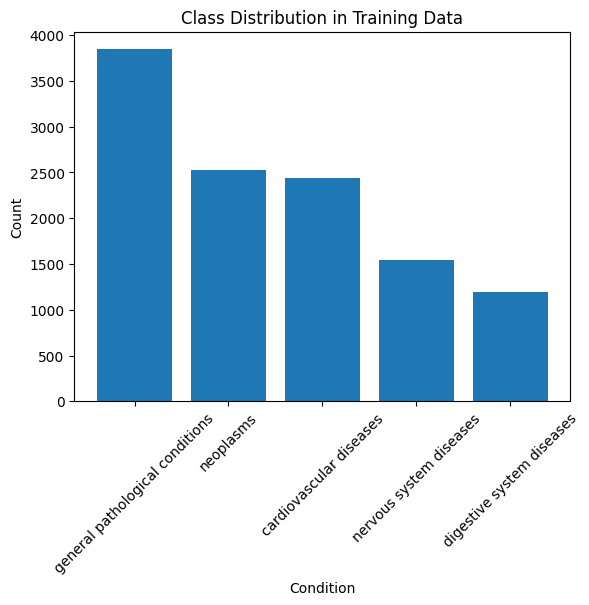

In [ ]:
class_counts = train_df["condition_name"].value_counts()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution in Training Data")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [ ]:
train_tokens = []
for text in train_df["medical_abstract"].astype(str):
    train_tokens.append(len(text.split()))

print("Token count min:", np.min(train_tokens))
print("Token count max:", np.max(train_tokens))
print("Token count mean:", np.mean(train_tokens))


Token count min: 24
Token count max: 596
Token count mean: 179.64060606060605


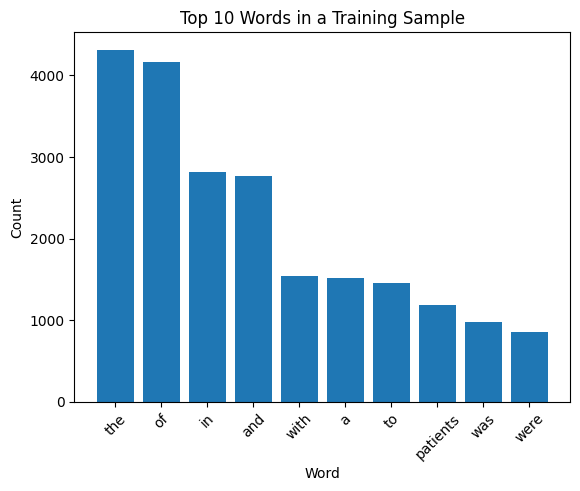

In [ ]:
eda_text = " ".join(train_df["medical_abstract"].astype(str).head(500).tolist()).lower()
tokens = word_tokenize(eda_text)
filtered_tokens = []
for word in tokens:
    if word.isalpha():
        filtered_tokens.append(word)

word_count = FreqDist(filtered_tokens)
top_words = []
top_counts = []
for tup in word_count.most_common(10):
    top_words.append(tup[0])
    top_counts.append(tup[1])

plt.bar(top_words, top_counts)
plt.title("Top 10 Words in a Training Sample")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


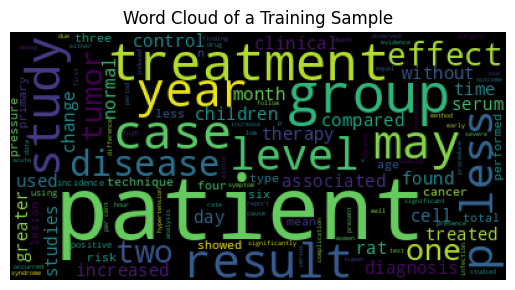

In [ ]:
wordcloud = WordCloud().generate(eda_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of a Training Sample")
plt.show()


##Preprocessing




In [ ]:
X = train_df["medical_abstract"].astype(str).str.lower()
y = train_df["condition_name"]
X_test_text = test_df["medical_abstract"].astype(str).str.lower()
y_test_text = test_df["condition_name"]
print(X.head())


0    tissue changes around loose prostheses. a cani...
1    neuropeptide y and neuron-specific enolase lev...
2    sexually transmitted diseases of the colon, re...
3    lipolytic factors associated with murine and h...
4    does carotid restenosis predict an increased r...
Name: medical_abstract, dtype: object


## Train / validation / test split



In [ ]:
X_train_text, X_val_text, y_train_text, y_val_text = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))
print("Test samples:", len(X_test_text))


Training samples: 9240
Validation samples: 2310
Test samples: 2888


In [ ]:
name_to_id = {
    "neoplasms": 0,
    "digestive system diseases": 1,
    "nervous system diseases": 2,
    "cardiovascular diseases": 3,
    "general pathological conditions": 4,
}

y_train_id = np.array(y_train_text.map(name_to_id))
y_val_id = np.array(y_val_text.map(name_to_id))
y_test_id = np.array(y_test_text.map(name_to_id))
print(y_train_id[:10])


[1 1 4 0 2 2 1 4 4 0]


## Shared Keras sequences for all sequence models




In [ ]:
num_words = 10000
max_len = 50
num_classes = 5

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=max_len, padding="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_text), maxlen=max_len, padding="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=max_len, padding="post")

print(X_train_seq.shape)
print(X_val_seq.shape)
print(X_test_seq.shape)


(9240, 50)
(2310, 50)
(2888, 50)


##SimpleRNN




### SimpleRNN Configuration 1


In [ ]:
model_simplernn_1 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    SimpleRNN(32),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model_simplernn_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_simplernn_1 = model_simplernn_1.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_simplernn_1 = np.argmax(model_simplernn_1.predict(X_val_seq), axis=1)
acc_simplernn_1 = accuracy_score(y_val_id, pred_simplernn_1)
f1_simplernn_1 = f1_score(y_val_id, pred_simplernn_1, average="macro")
print("SimpleRNN Configuration 1")
print("Validation Accuracy:", acc_simplernn_1)
print("Validation Macro F1:", f1_simplernn_1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.3051 - loss: 1.5497 - val_accuracy: 0.3848 - val_loss: 1.4581
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4556 - loss: 1.3237 - val_accuracy: 0.4242 - val_loss: 1.3652
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5557 - loss: 1.1390 - val_accuracy: 0.4082 - val_loss: 1.4008
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6395 - loss: 0.9633 - val_accuracy: 0.3736 - val_loss: 1.5149
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7090 - loss: 0.8081 - val_accuracy: 0.3714 - val_loss: 1.6443
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
SimpleRNN Configuration 1
Validation Accuracy: 0.37142857142857144
Validation Macro F1: 0.297585773402063


### SimpleRNN Configuration 2


In [ ]:
model_simplernn_2 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    SimpleRNN(32),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model_simplernn_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_simplernn_2 = model_simplernn_2.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_simplernn_2 = np.argmax(model_simplernn_2.predict(X_val_seq), axis=1)
acc_simplernn_2 = accuracy_score(y_val_id, pred_simplernn_2)
f1_simplernn_2 = f1_score(y_val_id, pred_simplernn_2, average="macro")
print("SimpleRNN Configuration 2")
print("Validation Accuracy:", acc_simplernn_2)
print("Validation Macro F1:", f1_simplernn_2)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.3263 - loss: 1.5267 - val_accuracy: 0.3922 - val_loss: 1.4162
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4884 - loss: 1.2616 - val_accuracy: 0.4260 - val_loss: 1.3760
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5994 - loss: 1.0486 - val_accuracy: 0.3758 - val_loss: 1.4830
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7018 - loss: 0.8296 - val_accuracy: 0.3610 - val_loss: 1.6384
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7617 - loss: 0.6548 - val_accuracy: 0.3390 - val_loss: 1.8373
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
SimpleRNN Configuration 2
Validation Accuracy: 0.33896103896103896
Validation Macro F1: 0.2923162498127865


### SimpleRNN Configuration 3


In [ ]:
model_simplernn_3 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
])

model_simplernn_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_simplernn_3 = model_simplernn_3.fit(
    X_train_seq,
    y_train_id,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_simplernn_3 = np.argmax(model_simplernn_3.predict(X_val_seq), axis=1)
acc_simplernn_3 = accuracy_score(y_val_id, pred_simplernn_3)
f1_simplernn_3 = f1_score(y_val_id, pred_simplernn_3, average="macro")
print("SimpleRNN Configuration 3")
print("Validation Accuracy:", acc_simplernn_3)
print("Validation Macro F1:", f1_simplernn_3)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.3161 - loss: 1.5519 - val_accuracy: 0.3329 - val_loss: 1.5281
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4000 - loss: 1.4168 - val_accuracy: 0.2866 - val_loss: 1.5465
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5773 - loss: 1.1140 - val_accuracy: 0.2745 - val_loss: 1.6670
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7162 - loss: 0.8058 - val_accuracy: 0.2788 - val_loss: 1.8855
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7700 - loss: 0.6209 - val_accuracy: 0.2597 - val_loss: 2.0920
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7938 - loss: 0.5256 - val_accuracy: 0.2571 - val_loss: 2.2149
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7936 - loss: 0.4842 - val_accuracy: 0.2580 - val_loss: 2.3172
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8026 - loss: 0.4468 - val_accuracy: 0.2580 - va

  Configuration  Validation Accuracy  Validation Macro F1
0   SimpleRNN 1             0.371429             0.297586
1   SimpleRNN 2             0.338961             0.292316
2   SimpleRNN 3             0.245022             0.212313
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Best SimpleRNN configuration: SimpleRNN 1
Test Accuracy: 0.38054016620498615
Test Macro F1: 0.3028205136902475
                                 precision    recall  f1-score   support

                      neoplasms       0.53      0.59      0.56       633
      digestive system diseases       0.13      0.06      0.08       299
        nervous system diseases       0.14      0.05      0.07       385
        cardiovascular diseases       0.40      0.65      0.49       610
general pathological conditions       0.32      0.30      0.31       961

                       accuracy                           0.38      2888
                      macro avg       0.30      0.33      0.30      2888
                   weighted avg 

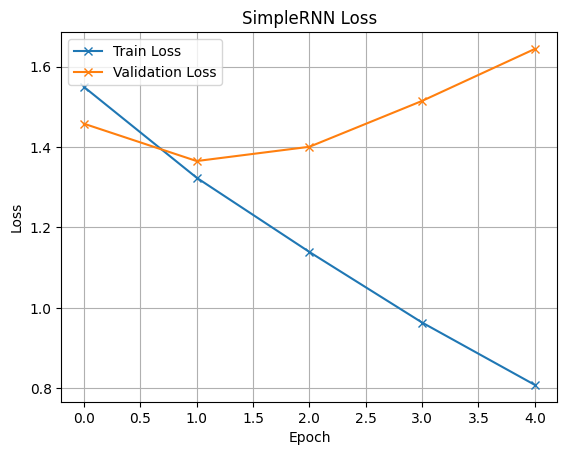

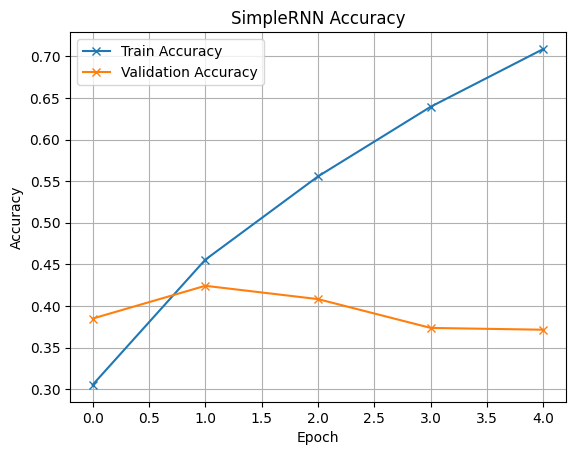

In [ ]:
simplernn_results = pd.DataFrame({
    "Configuration": ["SimpleRNN 1", "SimpleRNN 2", "SimpleRNN 3"],
    "Validation Accuracy": [acc_simplernn_1, acc_simplernn_2, acc_simplernn_3],
    "Validation Macro F1": [f1_simplernn_1, f1_simplernn_2, f1_simplernn_3],
})
print(simplernn_results)

if (f1_simplernn_1 >= f1_simplernn_2) and (f1_simplernn_1 >= f1_simplernn_3):
    best_simplernn_name = "SimpleRNN 1"
    simplernn_val_f1 = f1_simplernn_1
    best_simplernn_model = model_simplernn_1
    history_best_simplernn = history_simplernn_1
elif f1_simplernn_2 >= f1_simplernn_3:
    best_simplernn_name = "SimpleRNN 2"
    simplernn_val_f1 = f1_simplernn_2
    best_simplernn_model = model_simplernn_2
    history_best_simplernn = history_simplernn_2
else:
    best_simplernn_name = "SimpleRNN 3"
    simplernn_val_f1 = f1_simplernn_3
    best_simplernn_model = model_simplernn_3
    history_best_simplernn = history_simplernn_3

simplernn_test_pred = np.argmax(best_simplernn_model.predict(X_test_seq), axis=1)
simplernn_test_acc = accuracy_score(y_test_id, simplernn_test_pred)
simplernn_test_f1 = f1_score(y_test_id, simplernn_test_pred, average="macro")
print("Best SimpleRNN configuration:", best_simplernn_name)
print("Test Accuracy:", simplernn_test_acc)
print("Test Macro F1:", simplernn_test_f1)
print(classification_report(y_test_id, simplernn_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, simplernn_test_pred))

plt.plot(history_best_simplernn.history["loss"], label="Train Loss", marker="x")
plt.plot(history_best_simplernn.history["val_loss"], label="Validation Loss", marker="x")
plt.title("SimpleRNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_best_simplernn.history["accuracy"], label="Train Accuracy", marker="x")
plt.plot(history_best_simplernn.history["val_accuracy"], label="Validation Accuracy", marker="x")
plt.title("SimpleRNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


##  Bidirectional SimpleRNN




### BiSimpleRNN Configuration 1


In [ ]:
model_bisimplernn_1 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(SimpleRNN(32)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model_bisimplernn_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bisimplernn_1 = model_bisimplernn_1.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bisimplernn_1 = np.argmax(model_bisimplernn_1.predict(X_val_seq), axis=1)
acc_bisimplernn_1 = accuracy_score(y_val_id, pred_bisimplernn_1)
f1_bisimplernn_1 = f1_score(y_val_id, pred_bisimplernn_1, average="macro")
print("BiSimpleRNN Configuration 1")
print("Validation Accuracy:", acc_bisimplernn_1)
print("Validation Macro F1:", f1_bisimplernn_1)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.3166 - loss: 1.5444 - val_accuracy: 0.3775 - val_loss: 1.4707
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4632 - loss: 1.3048 - val_accuracy: 0.4294 - val_loss: 1.3587
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5815 - loss: 1.0604 - val_accuracy: 0.4108 - val_loss: 1.4006
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6761 - loss: 0.8538 - val_accuracy: 0.3792 - val_loss: 1.5003
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7389 - loss: 0.7003 - val_accuracy: 0.3675 - val_loss: 1.6553
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
BiSimpleRNN Configuration 1
Validation Accuracy: 0.36753246753246754
Validation Macro F1: 0.29965980335105186


### BiSimpleRNN Configuration 2


In [ ]:
model_bisimplernn_2 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(SimpleRNN(32)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model_bisimplernn_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bisimplernn_2 = model_bisimplernn_2.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bisimplernn_2 = np.argmax(model_bisimplernn_2.predict(X_val_seq), axis=1)
acc_bisimplernn_2 = accuracy_score(y_val_id, pred_bisimplernn_2)
f1_bisimplernn_2 = f1_score(y_val_id, pred_bisimplernn_2, average="macro")
print("BiSimpleRNN Configuration 2")
print("Validation Accuracy:", acc_bisimplernn_2)
print("Validation Macro F1:", f1_bisimplernn_2)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.3104 - loss: 1.5579 - val_accuracy: 0.3338 - val_loss: 1.5222
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4528 - loss: 1.3397 - val_accuracy: 0.4208 - val_loss: 1.3648
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6185 - loss: 1.0018 - val_accuracy: 0.3723 - val_loss: 1.4644
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7353 - loss: 0.7158 - val_accuracy: 0.3827 - val_loss: 1.5859
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7801 - loss: 0.5767 - val_accuracy: 0.3346 - val_loss: 1.7907
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
BiSimpleRNN Configuration 2
Validation Accuracy: 0.3346320346320346
Validation Macro F1: 0.3046953856273882


### BiSimpleRNN Configuration 3


In [ ]:
model_bisimplernn_3 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(SimpleRNN(32)),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
])

model_bisimplernn_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bisimplernn_3 = model_bisimplernn_3.fit(
    X_train_seq,
    y_train_id,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bisimplernn_3 = np.argmax(model_bisimplernn_3.predict(X_val_seq), axis=1)
acc_bisimplernn_3 = accuracy_score(y_val_id, pred_bisimplernn_3)
f1_bisimplernn_3 = f1_score(y_val_id, pred_bisimplernn_3, average="macro")
print("BiSimpleRNN Configuration 3")
print("Validation Accuracy:", acc_bisimplernn_3)
print("Validation Macro F1:", f1_bisimplernn_3)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.3135 - loss: 1.5498 - val_accuracy: 0.3303 - val_loss: 1.5292
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4676 - loss: 1.3132 - val_accuracy: 0.4035 - val_loss: 1.3942
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.6294 - loss: 0.9683 - val_accuracy: 0.3545 - val_loss: 1.6005
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7395 - loss: 0.7016 - val_accuracy: 0.3325 - val_loss: 1.7920
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7845 - loss: 0.5603 - val_accuracy: 0.3139 - val_loss: 1.9128
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7923 - loss: 0.4890 - val_accuracy: 0.3221 - val_loss: 2.0015
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7975 - loss: 0.4556 - val_accuracy: 0.3100 - val_loss: 2.1242
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8029 - loss: 0.4309 - val_accuracy: 0.329

   Configuration  Validation Accuracy  Validation Macro F1
0  BiSimpleRNN 1             0.367532             0.299660
1  BiSimpleRNN 2             0.334632             0.304695
2  BiSimpleRNN 3             0.316450             0.263289
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Best BiSimpleRNN configuration: BiSimpleRNN 2
Test Accuracy: 0.3376038781163435
Test Macro F1: 0.30784373468653053
                                 precision    recall  f1-score   support

                      neoplasms       0.52      0.42      0.47       633
      digestive system diseases       0.21      0.16      0.18       299
        nervous system diseases       0.17      0.11      0.13       385
        cardiovascular diseases       0.45      0.48      0.46       610
general pathological conditions       0.26      0.34      0.30       961

                       accuracy                           0.34      2888
                      macro avg       0.32      0.30      0.31      2888
                   weigh

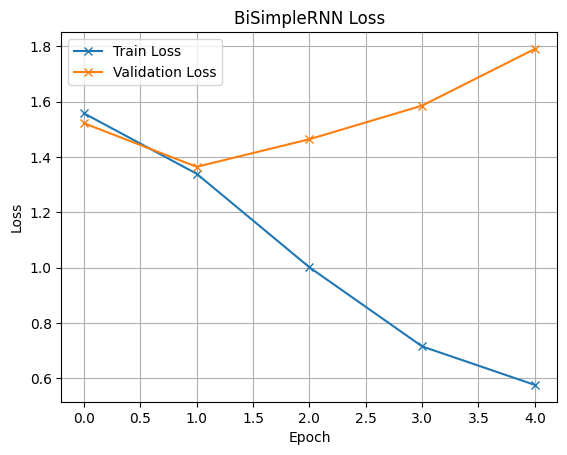

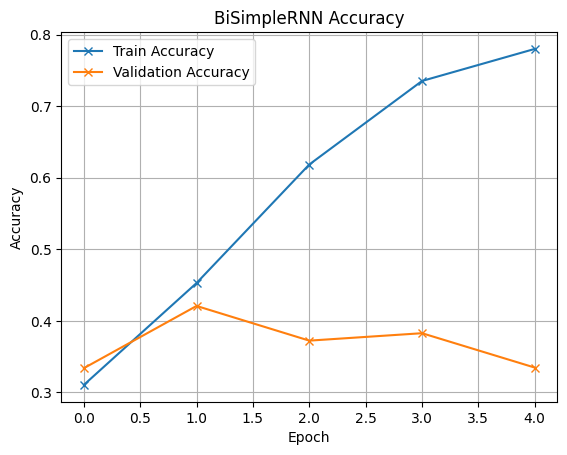

In [ ]:
bisimplernn_results = pd.DataFrame({
    "Configuration": ["BiSimpleRNN 1", "BiSimpleRNN 2", "BiSimpleRNN 3"],
    "Validation Accuracy": [acc_bisimplernn_1, acc_bisimplernn_2, acc_bisimplernn_3],
    "Validation Macro F1": [f1_bisimplernn_1, f1_bisimplernn_2, f1_bisimplernn_3],
})
print(bisimplernn_results)

if (f1_bisimplernn_1 >= f1_bisimplernn_2) and (f1_bisimplernn_1 >= f1_bisimplernn_3):
    best_bisimplernn_name = "BiSimpleRNN 1"
    bisimplernn_val_f1 = f1_bisimplernn_1
    best_bisimplernn_model = model_bisimplernn_1
    history_best_bisimplernn = history_bisimplernn_1
elif f1_bisimplernn_2 >= f1_bisimplernn_3:
    best_bisimplernn_name = "BiSimpleRNN 2"
    bisimplernn_val_f1 = f1_bisimplernn_2
    best_bisimplernn_model = model_bisimplernn_2
    history_best_bisimplernn = history_bisimplernn_2
else:
    best_bisimplernn_name = "BiSimpleRNN 3"
    bisimplernn_val_f1 = f1_bisimplernn_3
    best_bisimplernn_model = model_bisimplernn_3
    history_best_bisimplernn = history_bisimplernn_3

bisimplernn_test_pred = np.argmax(best_bisimplernn_model.predict(X_test_seq), axis=1)
bisimplernn_test_acc = accuracy_score(y_test_id, bisimplernn_test_pred)
bisimplernn_test_f1 = f1_score(y_test_id, bisimplernn_test_pred, average="macro")
print("Best BiSimpleRNN configuration:", best_bisimplernn_name)
print("Test Accuracy:", bisimplernn_test_acc)
print("Test Macro F1:", bisimplernn_test_f1)
print(classification_report(y_test_id, bisimplernn_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, bisimplernn_test_pred))

plt.plot(history_best_bisimplernn.history["loss"], label="Train Loss", marker="x")
plt.plot(history_best_bisimplernn.history["val_loss"], label="Validation Loss", marker="x")
plt.title("BiSimpleRNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_best_bisimplernn.history["accuracy"], label="Train Accuracy", marker="x")
plt.plot(history_best_bisimplernn.history["val_accuracy"], label="Validation Accuracy", marker="x")
plt.title("BiSimpleRNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


##TF-IDF + Logistic Regression




In [ ]:
tfidf_lr_1 = TfidfVectorizer()
X_train_lr_1 = tfidf_lr_1.fit_transform(X_train_text)
X_val_lr_1 = tfidf_lr_1.transform(X_val_text)
lr_model_1 = LogisticRegression()
lr_model_1.fit(X_train_lr_1, y_train_text)
lr_pred_1 = lr_model_1.predict(X_val_lr_1)
lr_acc_1 = accuracy_score(y_val_text, lr_pred_1)
lr_f1_1 = f1_score(y_val_text, lr_pred_1, average="macro")
print("LR Configuration 1")
print("Validation Accuracy:", lr_acc_1)
print("Validation Macro F1:", lr_f1_1)


LR Configuration 1
Validation Accuracy: 0.564069264069264
Validation Macro F1: 0.5382219230478151


In [ ]:
tfidf_lr_2 = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words="english")
X_train_lr_2 = tfidf_lr_2.fit_transform(X_train_text)
X_val_lr_2 = tfidf_lr_2.transform(X_val_text)
lr_model_2 = LogisticRegression()
lr_model_2.fit(X_train_lr_2, y_train_text)
lr_pred_2 = lr_model_2.predict(X_val_lr_2)
lr_acc_2 = accuracy_score(y_val_text, lr_pred_2)
lr_f1_2 = f1_score(y_val_text, lr_pred_2, average="macro")
print("LR Configuration 2")
print("Validation Accuracy:", lr_acc_2)
print("Validation Macro F1:", lr_f1_2)


LR Configuration 2
Validation Accuracy: 0.5692640692640693
Validation Macro F1: 0.5538035188114251


In [ ]:
tfidf_lr_3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_lr_3 = tfidf_lr_3.fit_transform(X_train_text)
X_val_lr_3 = tfidf_lr_3.transform(X_val_text)
lr_model_3 = LogisticRegression()
lr_model_3.fit(X_train_lr_3, y_train_text)
lr_pred_3 = lr_model_3.predict(X_val_lr_3)
lr_acc_3 = accuracy_score(y_val_text, lr_pred_3)
lr_f1_3 = f1_score(y_val_text, lr_pred_3, average="macro")
print("LR Configuration 3")
print("Validation Accuracy:", lr_acc_3)
print("Validation Macro F1:", lr_f1_3)


LR Configuration 3
Validation Accuracy: 0.5826839826839827
Validation Macro F1: 0.5627626591156145


In [ ]:
lr_results = pd.DataFrame({
    "Configuration": ["LR 1", "LR 2", "LR 3"],
    "Validation Accuracy": [lr_acc_1, lr_acc_2, lr_acc_3],
    "Validation Macro F1": [lr_f1_1, lr_f1_2, lr_f1_3],
})
print(lr_results)

if (lr_f1_1 >= lr_f1_2) and (lr_f1_1 >= lr_f1_3):
    best_lr_name = "LR 1"
    lr_val_f1 = lr_f1_1
    lr_test_pred = lr_model_1.predict(tfidf_lr_1.transform(X_test_text))
elif lr_f1_2 >= lr_f1_3:
    best_lr_name = "LR 2"
    lr_val_f1 = lr_f1_2
    lr_test_pred = lr_model_2.predict(tfidf_lr_2.transform(X_test_text))
else:
    best_lr_name = "LR 3"
    lr_val_f1 = lr_f1_3
    lr_test_pred = lr_model_3.predict(tfidf_lr_3.transform(X_test_text))

lr_test_acc = accuracy_score(y_test_text, lr_test_pred)
lr_test_f1 = f1_score(y_test_text, lr_test_pred, average="macro")
print("Best Logistic Regression configuration:", best_lr_name)
print("Test Accuracy:", lr_test_acc)
print("Test Macro F1:", lr_test_f1)
print(classification_report(y_test_text, lr_test_pred))
print(confusion_matrix(y_test_text, lr_test_pred))


  Configuration  Validation Accuracy  Validation Macro F1
0          LR 1             0.564069             0.538222
1          LR 2             0.569264             0.553804
2          LR 3             0.582684             0.562763
Best Logistic Regression configuration: LR 3
Test Accuracy: 0.5768698060941828
Test Macro F1: 0.5636597230875438
                                 precision    recall  f1-score   support

        cardiovascular diseases       0.66      0.65      0.66       610
      digestive system diseases       0.55      0.40      0.46       299
general pathological conditions       0.47      0.55      0.51       961
                      neoplasms       0.68      0.72      0.70       633
        nervous system diseases       0.58      0.43      0.49       385

                       accuracy                           0.58      2888
                      macro avg       0.59      0.55      0.56      2888
                   weighted avg       0.58      0.58      0.57      2

##TF-IDF + Multinomial Naive Bayes




In [ ]:
tfidf_nb_1 = TfidfVectorizer()
X_train_nb_1 = tfidf_nb_1.fit_transform(X_train_text)
X_val_nb_1 = tfidf_nb_1.transform(X_val_text)
nb_model_1 = MultinomialNB(alpha=1)
nb_model_1.fit(X_train_nb_1, y_train_text)
nb_pred_1 = nb_model_1.predict(X_val_nb_1)
nb_acc_1 = accuracy_score(y_val_text, nb_pred_1)
nb_f1_1 = f1_score(y_val_text, nb_pred_1, average="macro")
print("NB Configuration 1")
print("Validation Accuracy:", nb_acc_1)
print("Validation Macro F1:", nb_f1_1)


NB Configuration 1
Validation Accuracy: 0.49393939393939396
Validation Macro F1: 0.34742087296407675


In [ ]:
tfidf_nb_2 = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words="english")
X_train_nb_2 = tfidf_nb_2.fit_transform(X_train_text)
X_val_nb_2 = tfidf_nb_2.transform(X_val_text)
nb_model_2 = MultinomialNB(alpha=1)
nb_model_2.fit(X_train_nb_2, y_train_text)
nb_pred_2 = nb_model_2.predict(X_val_nb_2)
nb_acc_2 = accuracy_score(y_val_text, nb_pred_2)
nb_f1_2 = f1_score(y_val_text, nb_pred_2, average="macro")
print("NB Configuration 2")
print("Validation Accuracy:", nb_acc_2)
print("Validation Macro F1:", nb_f1_2)


NB Configuration 2
Validation Accuracy: 0.5636363636363636
Validation Macro F1: 0.5295664879283966


In [ ]:
tfidf_nb_3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_nb_3 = tfidf_nb_3.fit_transform(X_train_text)
X_val_nb_3 = tfidf_nb_3.transform(X_val_text)
nb_model_3 = MultinomialNB(alpha=1)
nb_model_3.fit(X_train_nb_3, y_train_text)
nb_pred_3 = nb_model_3.predict(X_val_nb_3)
nb_acc_3 = accuracy_score(y_val_text, nb_pred_3)
nb_f1_3 = f1_score(y_val_text, nb_pred_3, average="macro")
print("NB Configuration 3")
print("Validation Accuracy:", nb_acc_3)
print("Validation Macro F1:", nb_f1_3)


NB Configuration 3
Validation Accuracy: 0.5865800865800865
Validation Macro F1: 0.5535146972263159


In [ ]:
nb_results = pd.DataFrame({
    "Configuration": ["NB 1", "NB 2", "NB 3"],
    "Validation Accuracy": [nb_acc_1, nb_acc_2, nb_acc_3],
    "Validation Macro F1": [nb_f1_1, nb_f1_2, nb_f1_3],
})
print(nb_results)

if (nb_f1_1 >= nb_f1_2) and (nb_f1_1 >= nb_f1_3):
    best_nb_name = "NB 1"
    nb_val_f1 = nb_f1_1
    nb_test_pred = nb_model_1.predict(tfidf_nb_1.transform(X_test_text))
elif nb_f1_2 >= nb_f1_3:
    best_nb_name = "NB 2"
    nb_val_f1 = nb_f1_2
    nb_test_pred = nb_model_2.predict(tfidf_nb_2.transform(X_test_text))
else:
    best_nb_name = "NB 3"
    nb_val_f1 = nb_f1_3
    nb_test_pred = nb_model_3.predict(tfidf_nb_3.transform(X_test_text))

nb_test_acc = accuracy_score(y_test_text, nb_test_pred)
nb_test_f1 = f1_score(y_test_text, nb_test_pred, average="macro")
print("Best Naive Bayes configuration:", best_nb_name)
print("Test Accuracy:", nb_test_acc)
print("Test Macro F1:", nb_test_f1)
print(classification_report(y_test_text, nb_test_pred))
print(confusion_matrix(y_test_text, nb_test_pred))


  Configuration  Validation Accuracy  Validation Macro F1
0          NB 1             0.493939             0.347421
1          NB 2             0.563636             0.529566
2          NB 3             0.586580             0.553515
Best Naive Bayes configuration: NB 3
Test Accuracy: 0.5834487534626038
Test Macro F1: 0.5606167021291567
                                 precision    recall  f1-score   support

        cardiovascular diseases       0.66      0.71      0.69       610
      digestive system diseases       0.57      0.32      0.41       299
general pathological conditions       0.47      0.53      0.50       961
                      neoplasms       0.67      0.77      0.71       633
        nervous system diseases       0.62      0.41      0.50       385

                       accuracy                           0.58      2888
                      macro avg       0.60      0.55      0.56      2888
                   weighted avg       0.58      0.58      0.58      2888

[[4

## GRU



### GRU Configuration 1


In [ ]:
model_gru_1 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    GRU(32),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model_gru_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_gru_1 = model_gru_1.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_gru_1 = np.argmax(model_gru_1.predict(X_val_seq), axis=1)
acc_gru_1 = accuracy_score(y_val_id, pred_gru_1)
f1_gru_1 = f1_score(y_val_id, pred_gru_1, average="macro")
print("GRU Configuration 1")
print("Validation Accuracy:", acc_gru_1)
print("Validation Macro F1:", f1_gru_1)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.3278 - loss: 1.5456 - val_accuracy: 0.3346 - val_loss: 1.5154
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4044 - loss: 1.4020 - val_accuracy: 0.4481 - val_loss: 1.3139
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5449 - loss: 1.1467 - val_accuracy: 0.4446 - val_loss: 1.3001
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6224 - loss: 0.9726 - val_accuracy: 0.4277 - val_loss: 1.4148
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6784 - loss: 0.8444 - val_accuracy: 0.4104 - val_loss: 1.4710
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
GRU Configuration 1
Validation Accuracy: 0.4103896103896104
Validation Macro F1: 0.38717668448548775


### GRU Configuration 2


In [ ]:
model_gru_2 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    GRU(32),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model_gru_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_gru_2 = model_gru_2.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_gru_2 = np.argmax(model_gru_2.predict(X_val_seq), axis=1)
acc_gru_2 = accuracy_score(y_val_id, pred_gru_2)
f1_gru_2 = f1_score(y_val_id, pred_gru_2, average="macro")
print("GRU Configuration 2")
print("Validation Accuracy:", acc_gru_2)
print("Validation Macro F1:", f1_gru_2)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3289 - loss: 1.5412 - val_accuracy: 0.3329 - val_loss: 1.5067
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4268 - loss: 1.3523 - val_accuracy: 0.4675 - val_loss: 1.2899
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5552 - loss: 1.0940 - val_accuracy: 0.4645 - val_loss: 1.3252
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6340 - loss: 0.9298 - val_accuracy: 0.4338 - val_loss: 1.4004
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6777 - loss: 0.8212 - val_accuracy: 0.4160 - val_loss: 1.5301
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
GRU Configuration 2
Validation Accuracy: 0.416017316017316
Validation Macro F1: 0.36584826682705945


### GRU Configuration 3


In [ ]:
model_gru_3 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    GRU(32),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
])

model_gru_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_gru_3 = model_gru_3.fit(
    X_train_seq,
    y_train_id,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_gru_3 = np.argmax(model_gru_3.predict(X_val_seq), axis=1)
acc_gru_3 = accuracy_score(y_val_id, pred_gru_3)
f1_gru_3 = f1_score(y_val_id, pred_gru_3, average="macro")
print("GRU Configuration 3")
print("Validation Accuracy:", acc_gru_3)
print("Validation Macro F1:", f1_gru_3)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3292 - loss: 1.5317 - val_accuracy: 0.3502 - val_loss: 1.4909
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4601 - loss: 1.2924 - val_accuracy: 0.4766 - val_loss: 1.2751
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5799 - loss: 1.0632 - val_accuracy: 0.4619 - val_loss: 1.3158
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6300 - loss: 0.9195 - val_accuracy: 0.4364 - val_loss: 1.4803
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6818 - loss: 0.8110 - val_accuracy: 0.3961 - val_loss: 1.5165
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7140 - loss: 0.7305 - val_accuracy: 0.4030 - val_loss: 1.6701
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7358 - loss: 0.6636 - val_accuracy: 0.3918 - val_loss: 1.7543
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7516 - loss: 0.6105 - val_accuracy: 0.3905 - 

  Configuration  Validation Accuracy  Validation Macro F1
0         GRU 1             0.410390             0.387177
1         GRU 2             0.416017             0.365848
2         GRU 3             0.352381             0.333864
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best GRU configuration: GRU 1
Test Accuracy: 0.4200138504155125
Test Macro F1: 0.3926180481952296
                                 precision    recall  f1-score   support

                      neoplasms       0.57      0.60      0.58       633
      digestive system diseases       0.26      0.28      0.27       299
        nervous system diseases       0.26      0.19      0.22       385
        cardiovascular diseases       0.55      0.50      0.52       610
general pathological conditions       0.35      0.39      0.37       961

                       accuracy                           0.42      2888
                      macro avg       0.40      0.39      0.39      2888
                   weighted avg       0.42   

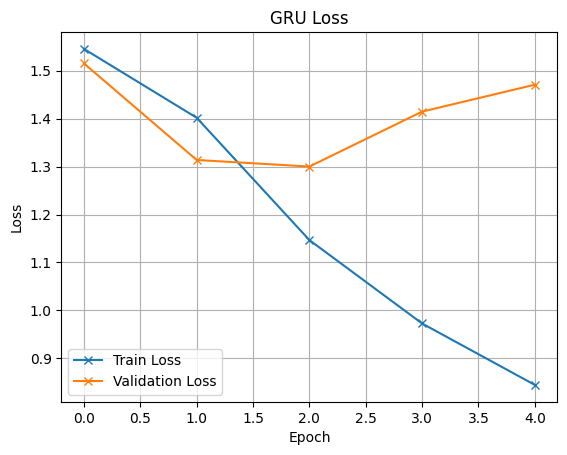

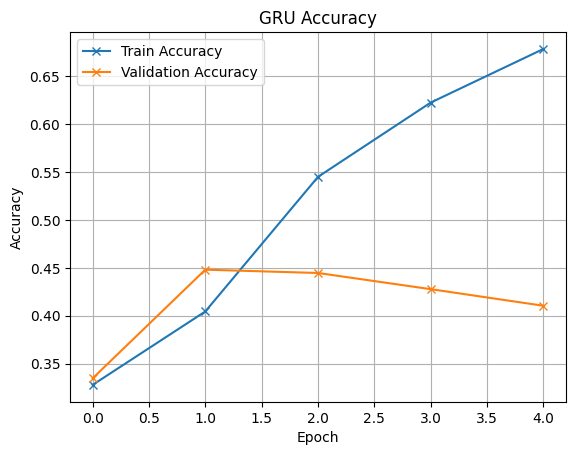

In [ ]:
gru_results = pd.DataFrame({
    "Configuration": ["GRU 1", "GRU 2", "GRU 3"],
    "Validation Accuracy": [acc_gru_1, acc_gru_2, acc_gru_3],
    "Validation Macro F1": [f1_gru_1, f1_gru_2, f1_gru_3],
})
print(gru_results)

if (f1_gru_1 >= f1_gru_2) and (f1_gru_1 >= f1_gru_3):
    best_gru_name = "GRU 1"
    gru_val_f1 = f1_gru_1
    best_gru_model = model_gru_1
    history_best_gru = history_gru_1
elif f1_gru_2 >= f1_gru_3:
    best_gru_name = "GRU 2"
    gru_val_f1 = f1_gru_2
    best_gru_model = model_gru_2
    history_best_gru = history_gru_2
else:
    best_gru_name = "GRU 3"
    gru_val_f1 = f1_gru_3
    best_gru_model = model_gru_3
    history_best_gru = history_gru_3

gru_test_pred = np.argmax(best_gru_model.predict(X_test_seq), axis=1)
gru_test_acc = accuracy_score(y_test_id, gru_test_pred)
gru_test_f1 = f1_score(y_test_id, gru_test_pred, average="macro")
print("Best GRU configuration:", best_gru_name)
print("Test Accuracy:", gru_test_acc)
print("Test Macro F1:", gru_test_f1)
print(classification_report(y_test_id, gru_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, gru_test_pred))

plt.plot(history_best_gru.history["loss"], label="Train Loss", marker="x")
plt.plot(history_best_gru.history["val_loss"], label="Validation Loss", marker="x")
plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_best_gru.history["accuracy"], label="Train Accuracy", marker="x")
plt.plot(history_best_gru.history["val_accuracy"], label="Validation Accuracy", marker="x")
plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


##  TF-IDF + Random Forest





In [ ]:
tfidf_rf_1 = TfidfVectorizer()
X_train_rf_1 = tfidf_rf_1.fit_transform(X_train_text)
X_val_rf_1 = tfidf_rf_1.transform(X_val_text)
rf_model_1 = RandomForestClassifier()
rf_model_1.fit(X_train_rf_1, y_train_text)
rf_pred_1 = rf_model_1.predict(X_val_rf_1)
rf_acc_1 = accuracy_score(y_val_text, rf_pred_1)
rf_f1_1 = f1_score(y_val_text, rf_pred_1, average="macro")
print("RF Configuration 1")
print("Validation Accuracy:", rf_acc_1)
print("Validation Macro F1:", rf_f1_1)


RF Configuration 1
Validation Accuracy: 0.4779220779220779
Validation Macro F1: 0.4207687862567009


In [ ]:
tfidf_rf_2 = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words="english")
X_train_rf_2 = tfidf_rf_2.fit_transform(X_train_text)
X_val_rf_2 = tfidf_rf_2.transform(X_val_text)
rf_model_2 = RandomForestClassifier()
rf_model_2.fit(X_train_rf_2, y_train_text)
rf_pred_2 = rf_model_2.predict(X_val_rf_2)
rf_acc_2 = accuracy_score(y_val_text, rf_pred_2)
rf_f1_2 = f1_score(y_val_text, rf_pred_2, average="macro")
print("RF Configuration 2")
print("Validation Accuracy:", rf_acc_2)
print("Validation Macro F1:", rf_f1_2)


RF Configuration 2
Validation Accuracy: 0.48917748917748916
Validation Macro F1: 0.4629967231034061


In [ ]:
tfidf_rf_3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_rf_3 = tfidf_rf_3.fit_transform(X_train_text)
X_val_rf_3 = tfidf_rf_3.transform(X_val_text)
rf_model_3 = RandomForestClassifier()
rf_model_3.fit(X_train_rf_3, y_train_text)
rf_pred_3 = rf_model_3.predict(X_val_rf_3)
rf_acc_3 = accuracy_score(y_val_text, rf_pred_3)
rf_f1_3 = f1_score(y_val_text, rf_pred_3, average="macro")
print("RF Configuration 3")
print("Validation Accuracy:", rf_acc_3)
print("Validation Macro F1:", rf_f1_3)


RF Configuration 3
Validation Accuracy: 0.5004329004329005
Validation Macro F1: 0.4769255348458433


In [ ]:
rf_results = pd.DataFrame({
    "Configuration": ["RF 1", "RF 2", "RF 3"],
    "Validation Accuracy": [rf_acc_1, rf_acc_2, rf_acc_3],
    "Validation Macro F1": [rf_f1_1, rf_f1_2, rf_f1_3],
})
print(rf_results)

if (rf_f1_1 >= rf_f1_2) and (rf_f1_1 >= rf_f1_3):
    best_rf_name = "RF 1"
    rf_val_f1 = rf_f1_1
    rf_test_pred = rf_model_1.predict(tfidf_rf_1.transform(X_test_text))
elif rf_f1_2 >= rf_f1_3:
    best_rf_name = "RF 2"
    rf_val_f1 = rf_f1_2
    rf_test_pred = rf_model_2.predict(tfidf_rf_2.transform(X_test_text))
else:
    best_rf_name = "RF 3"
    rf_val_f1 = rf_f1_3
    rf_test_pred = rf_model_3.predict(tfidf_rf_3.transform(X_test_text))

rf_test_acc = accuracy_score(y_test_text, rf_test_pred)
rf_test_f1 = f1_score(y_test_text, rf_test_pred, average="macro")
print("Best Random Forest configuration:", best_rf_name)
print("Test Accuracy:", rf_test_acc)
print("Test Macro F1:", rf_test_f1)
print(classification_report(y_test_text, rf_test_pred))
print(confusion_matrix(y_test_text, rf_test_pred))


  Configuration  Validation Accuracy  Validation Macro F1
0          RF 1             0.477922             0.420769
1          RF 2             0.489177             0.462997
2          RF 3             0.500433             0.476926
Best Random Forest configuration: RF 3
Test Accuracy: 0.4903047091412742
Test Macro F1: 0.4766178237685145
                                 precision    recall  f1-score   support

        cardiovascular diseases       0.56      0.63      0.60       610
      digestive system diseases       0.39      0.34      0.36       299
general pathological conditions       0.37      0.38      0.37       961
                      neoplasms       0.63      0.69      0.66       633
        nervous system diseases       0.46      0.33      0.39       385

                       accuracy                           0.49      2888
                      macro avg       0.48      0.47      0.48      2888
                   weighted avg       0.48      0.49      0.48      2888

[

##LSTM




### LSTM Configuration 1


In [ ]:
model_lstm_1 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    LSTM(32),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model_lstm_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_lstm_1 = model_lstm_1.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_lstm_1 = np.argmax(model_lstm_1.predict(X_val_seq), axis=1)
acc_lstm_1 = accuracy_score(y_val_id, pred_lstm_1)
f1_lstm_1 = f1_score(y_val_id, pred_lstm_1, average="macro")
print("LSTM Configuration 1")
print("Validation Accuracy:", acc_lstm_1)
print("Validation Macro F1:", f1_lstm_1)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3311 - loss: 1.5437 - val_accuracy: 0.3329 - val_loss: 1.5071
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4456 - loss: 1.3065 - val_accuracy: 0.4680 - val_loss: 1.2740
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5739 - loss: 1.0794 - val_accuracy: 0.4537 - val_loss: 1.3061
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6459 - loss: 0.9336 - val_accuracy: 0.4654 - val_loss: 1.3246
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7084 - loss: 0.8049 - val_accuracy: 0.4537 - val_loss: 1.4106
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
LSTM Configuration 1
Validation Accuracy: 0.4536796536796537
Validation Macro F1: 0.44701287473250473


### LSTM Configuration 2


In [ ]:
model_lstm_2 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    LSTM(32),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model_lstm_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_lstm_2 = model_lstm_2.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_lstm_2 = np.argmax(model_lstm_2.predict(X_val_seq), axis=1)
acc_lstm_2 = accuracy_score(y_val_id, pred_lstm_2)
f1_lstm_2 = f1_score(y_val_id, pred_lstm_2, average="macro")
print("LSTM Configuration 2")
print("Validation Accuracy:", acc_lstm_2)
print("Validation Macro F1:", f1_lstm_2)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3357 - loss: 1.5241 - val_accuracy: 0.4260 - val_loss: 1.4214
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4853 - loss: 1.2458 - val_accuracy: 0.4957 - val_loss: 1.2424
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5820 - loss: 1.0481 - val_accuracy: 0.4758 - val_loss: 1.2590
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6584 - loss: 0.8949 - val_accuracy: 0.4649 - val_loss: 1.2831
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7041 - loss: 0.7906 - val_accuracy: 0.4463 - val_loss: 1.4522
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Configuration 2
Validation Accuracy: 0.44632034632034634
Validation Macro F1: 0.4224620815899923


### LSTM Configuration 3


In [ ]:
model_lstm_3 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    LSTM(32),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
])

model_lstm_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_lstm_3 = model_lstm_3.fit(
    X_train_seq,
    y_train_id,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_lstm_3 = np.argmax(model_lstm_3.predict(X_val_seq), axis=1)
acc_lstm_3 = accuracy_score(y_val_id, pred_lstm_3)
f1_lstm_3 = f1_score(y_val_id, pred_lstm_3, average="macro")
print("LSTM Configuration 3")
print("Validation Accuracy:", acc_lstm_3)
print("Validation Macro F1:", f1_lstm_3)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3394 - loss: 1.5235 - val_accuracy: 0.3792 - val_loss: 1.4030
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4958 - loss: 1.2413 - val_accuracy: 0.4632 - val_loss: 1.2919
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5868 - loss: 1.0508 - val_accuracy: 0.4831 - val_loss: 1.2782
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6646 - loss: 0.9062 - val_accuracy: 0.4749 - val_loss: 1.3316
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7170 - loss: 0.7648 - val_accuracy: 0.4597 - val_loss: 1.3866
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7565 - loss: 0.6630 - val_accuracy: 0.4407 - val_loss: 1.5365
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7719 - loss: 0.5979 - val_accuracy: 0.4338 - val_loss: 1.6443
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7826 - loss: 0.5590 - val_accuracy: 0.4242 - va

  Configuration  Validation Accuracy  Validation Macro F1
0        LSTM 1             0.453680             0.447013
1        LSTM 2             0.446320             0.422462
2        LSTM 3             0.399567             0.386592
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best LSTM configuration: LSTM 1
Test Accuracy: 0.47229916897506924
Test Macro F1: 0.4632901011440758
                                 precision    recall  f1-score   support

                      neoplasms       0.59      0.68      0.63       633
      digestive system diseases       0.38      0.45      0.42       299
        nervous system diseases       0.38      0.36      0.37       385
        cardiovascular diseases       0.53      0.65      0.58       610
general pathological conditions       0.38      0.27      0.32       961

                       accuracy                           0.47      2888
                      macro avg       0.45      0.48      0.46      2888
                   weighted avg       0.46

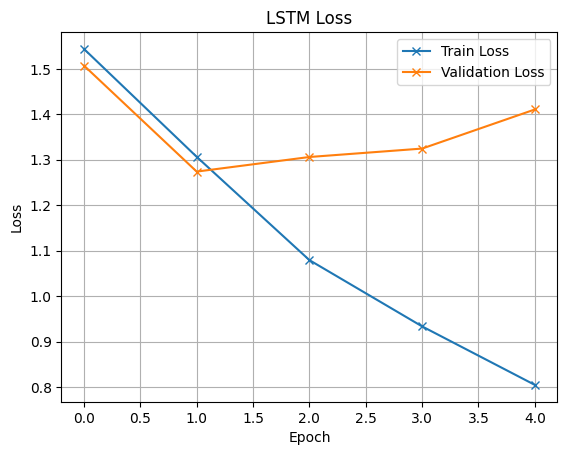

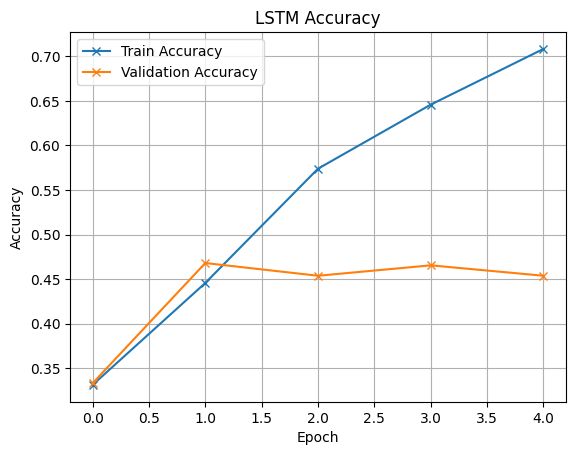

In [ ]:
lstm_results = pd.DataFrame({
    "Configuration": ["LSTM 1", "LSTM 2", "LSTM 3"],
    "Validation Accuracy": [acc_lstm_1, acc_lstm_2, acc_lstm_3],
    "Validation Macro F1": [f1_lstm_1, f1_lstm_2, f1_lstm_3],
})
print(lstm_results)

if (f1_lstm_1 >= f1_lstm_2) and (f1_lstm_1 >= f1_lstm_3):
    best_lstm_name = "LSTM 1"
    lstm_val_f1 = f1_lstm_1
    best_lstm_model = model_lstm_1
    history_best_lstm = history_lstm_1
elif f1_lstm_2 >= f1_lstm_3:
    best_lstm_name = "LSTM 2"
    lstm_val_f1 = f1_lstm_2
    best_lstm_model = model_lstm_2
    history_best_lstm = history_lstm_2
else:
    best_lstm_name = "LSTM 3"
    lstm_val_f1 = f1_lstm_3
    best_lstm_model = model_lstm_3
    history_best_lstm = history_lstm_3

lstm_test_pred = np.argmax(best_lstm_model.predict(X_test_seq), axis=1)
lstm_test_acc = accuracy_score(y_test_id, lstm_test_pred)
lstm_test_f1 = f1_score(y_test_id, lstm_test_pred, average="macro")
print("Best LSTM configuration:", best_lstm_name)
print("Test Accuracy:", lstm_test_acc)
print("Test Macro F1:", lstm_test_f1)
print(classification_report(y_test_id, lstm_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, lstm_test_pred))

plt.plot(history_best_lstm.history["loss"], label="Train Loss", marker="x")
plt.plot(history_best_lstm.history["val_loss"], label="Validation Loss", marker="x")
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_best_lstm.history["accuracy"], label="Train Accuracy", marker="x")
plt.plot(history_best_lstm.history["val_accuracy"], label="Validation Accuracy", marker="x")
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## Bidirectional GRU




### BiGRU Configuration 1


In [ ]:
model_bigru_1 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(GRU(32)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model_bigru_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bigru_1 = model_bigru_1.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bigru_1 = np.argmax(model_bigru_1.predict(X_val_seq), axis=1)
acc_bigru_1 = accuracy_score(y_val_id, pred_bigru_1)
f1_bigru_1 = f1_score(y_val_id, pred_bigru_1, average="macro")
print("BiGRU Configuration 1")
print("Validation Accuracy:", acc_bigru_1)
print("Validation Macro F1:", f1_bigru_1)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3289 - loss: 1.5427 - val_accuracy: 0.3329 - val_loss: 1.5195
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4103 - loss: 1.3944 - val_accuracy: 0.4636 - val_loss: 1.3048
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5554 - loss: 1.1119 - val_accuracy: 0.4545 - val_loss: 1.2999
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6562 - loss: 0.8958 - val_accuracy: 0.4286 - val_loss: 1.3748
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7240 - loss: 0.7145 - val_accuracy: 0.4139 - val_loss: 1.5002
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
BiGRU Configuration 1
Validation Accuracy: 0.41385281385281386
Validation Macro F1: 0.3754000665362375


BiGRU Configuration 3

In [ ]:
model_bigru_2 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model_bigru_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bigru_2 = model_bigru_2.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bigru_2 = np.argmax(model_bigru_2.predict(X_val_seq), axis=1)
acc_bigru_2 = accuracy_score(y_val_id, pred_bigru_2)
f1_bigru_2 = f1_score(y_val_id, pred_bigru_2, average="macro")
print("BiGRU Configuration 2")
print("Validation Accuracy:", acc_bigru_2)
print("Validation Macro F1:", f1_bigru_2)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3298 - loss: 1.5350 - val_accuracy: 0.3381 - val_loss: 1.5056
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4639 - loss: 1.2987 - val_accuracy: 0.4870 - val_loss: 1.2619
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5864 - loss: 1.0319 - val_accuracy: 0.4563 - val_loss: 1.2902
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6728 - loss: 0.8306 - val_accuracy: 0.4424 - val_loss: 1.4161
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7281 - loss: 0.6817 - val_accuracy: 0.4126 - val_loss: 1.5163
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
BiGRU Configuration 2
Validation Accuracy: 0.41255411255411256
Validation Macro F1: 0.4023947629607876


### BiGRU Configuration 3


In [ ]:
model_bigru_3 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(GRU(32)),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
])

model_bigru_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bigru_3 = model_bigru_3.fit(
    X_train_seq,
    y_train_id,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bigru_3 = np.argmax(model_bigru_3.predict(X_val_seq), axis=1)
acc_bigru_3 = accuracy_score(y_val_id, pred_bigru_3)
f1_bigru_3 = f1_score(y_val_id, pred_bigru_3, average="macro")
print("BiGRU Configuration 3")
print("Validation Accuracy:", acc_bigru_3)
print("Validation Macro F1:", f1_bigru_3)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3359 - loss: 1.5281 - val_accuracy: 0.3732 - val_loss: 1.4757
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4793 - loss: 1.2690 - val_accuracy: 0.4662 - val_loss: 1.2911
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5830 - loss: 1.0434 - val_accuracy: 0.4385 - val_loss: 1.3408
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6715 - loss: 0.8499 - val_accuracy: 0.4299 - val_loss: 1.4650
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7354 - loss: 0.6879 - val_accuracy: 0.4216 - val_loss: 1.5693
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7595 - loss: 0.5856 - val_accuracy: 0.4039 - val_loss: 1.6634
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7808 - loss: 0.5131 - val_accuracy: 0.4004 - val_loss: 1.8155
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7872 - loss: 0.4797 - val_accuracy: 0.392

  Configuration  Validation Accuracy  Validation Macro F1
0       BiGRU 1             0.413853             0.375400
1       BiGRU 2             0.412554             0.402395
2       BiGRU 3             0.380952             0.363150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Best BiGRU configuration: BiGRU 2
Test Accuracy: 0.4283240997229917
Test Macro F1: 0.4141866634385445
                                 precision    recall  f1-score   support

                      neoplasms       0.54      0.61      0.57       633
      digestive system diseases       0.30      0.29      0.29       299
        nervous system diseases       0.39      0.30      0.34       385
        cardiovascular diseases       0.53      0.54      0.53       610
general pathological conditions       0.33      0.33      0.33       961

                       accuracy                           0.43      2888
                      macro avg       0.42      0.41      0.41      2888
                   weighted avg       0.4

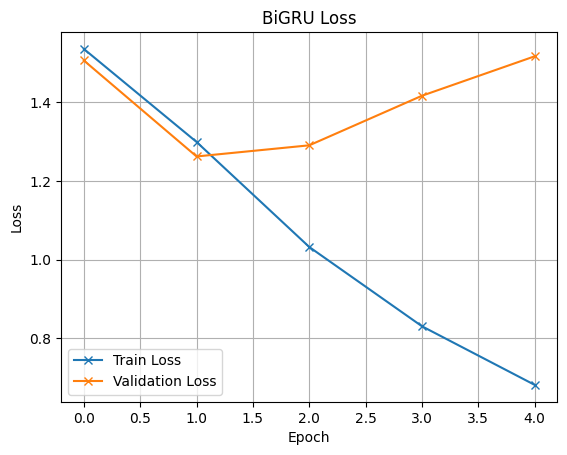

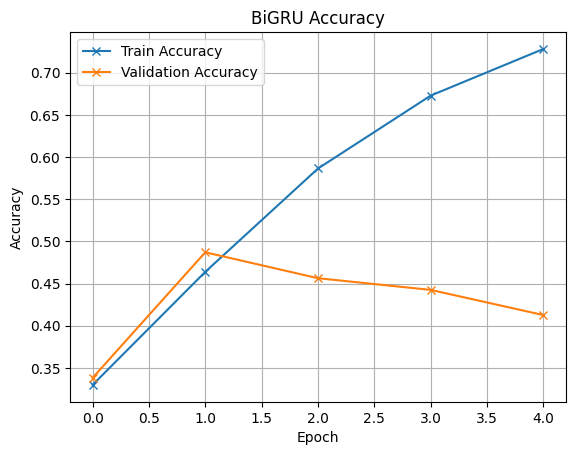

In [ ]:
bigru_results = pd.DataFrame({
    "Configuration": ["BiGRU 1", "BiGRU 2", "BiGRU 3"],
    "Validation Accuracy": [acc_bigru_1, acc_bigru_2, acc_bigru_3],
    "Validation Macro F1": [f1_bigru_1, f1_bigru_2, f1_bigru_3],
})
print(bigru_results)

if (f1_bigru_1 >= f1_bigru_2) and (f1_bigru_1 >= f1_bigru_3):
    best_bigru_name = "BiGRU 1"
    bigru_val_f1 = f1_bigru_1
    best_bigru_model = model_bigru_1
    history_best_bigru = history_bigru_1
elif f1_bigru_2 >= f1_bigru_3:
    best_bigru_name = "BiGRU 2"
    bigru_val_f1 = f1_bigru_2
    best_bigru_model = model_bigru_2
    history_best_bigru = history_bigru_2
else:
    best_bigru_name = "BiGRU 3"
    bigru_val_f1 = f1_bigru_3
    best_bigru_model = model_bigru_3
    history_best_bigru = history_bigru_3

bigru_test_pred = np.argmax(best_bigru_model.predict(X_test_seq), axis=1)
bigru_test_acc = accuracy_score(y_test_id, bigru_test_pred)
bigru_test_f1 = f1_score(y_test_id, bigru_test_pred, average="macro")
print("Best BiGRU configuration:", best_bigru_name)
print("Test Accuracy:", bigru_test_acc)
print("Test Macro F1:", bigru_test_f1)
print(classification_report(y_test_id, bigru_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, bigru_test_pred))

plt.plot(history_best_bigru.history["loss"], label="Train Loss", marker="x")
plt.plot(history_best_bigru.history["val_loss"], label="Validation Loss", marker="x")
plt.title("BiGRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_best_bigru.history["accuracy"], label="Train Accuracy", marker="x")
plt.plot(history_best_bigru.history["val_accuracy"], label="Validation Accuracy", marker="x")
plt.title("BiGRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Shared Word2Vec + Logistic Regression




In [ ]:
train_sentences = []
for text in X_train_text:
    train_sentences.append(text.split())


In [ ]:
w2v_1 = Word2Vec(vector_size=10, window=3, sg=1, min_count=1)
w2v_1.build_vocab(train_sentences)
w2v_1.train(train_sentences, total_examples=len(train_sentences), epochs=10)


(13272318, 16633750)

In [ ]:
w2v_2 = Word2Vec(vector_size=10, window=3, sg=0, min_count=1)
w2v_2.build_vocab(train_sentences)
w2v_2.train(train_sentences, total_examples=len(train_sentences), epochs=10)


(13272009, 16633750)

In [ ]:
w2v_3 = Word2Vec(vector_size=10, window=3, sg=1, min_count=1)
w2v_3.build_vocab(train_sentences)
w2v_3.train(train_sentences, total_examples=len(train_sentences), epochs=10)


(13273385, 16633750)

In [ ]:
def make_doc_matrix(text_series, w2v_model):
    rows = []
    for text in text_series:
        words = text.split()
        vecs = []
        for w in words:
            if w in w2v_model.wv:
                vecs.append(w2v_model.wv[w])
        if len(vecs) == 0:
            rows.append(np.zeros(w2v_model.vector_size))
        else:
            rows.append(np.mean(vecs, axis=0))
    return np.array(rows)

X_train_w2v_1 = make_doc_matrix(X_train_text, w2v_1)
X_val_w2v_1 = make_doc_matrix(X_val_text, w2v_1)
X_test_w2v_1 = make_doc_matrix(X_test_text, w2v_1)

X_train_w2v_2 = make_doc_matrix(X_train_text, w2v_2)
X_val_w2v_2 = make_doc_matrix(X_val_text, w2v_2)
X_test_w2v_2 = make_doc_matrix(X_test_text, w2v_2)

X_train_w2v_3 = make_doc_matrix(X_train_text, w2v_3)
X_val_w2v_3 = make_doc_matrix(X_val_text, w2v_3)
X_test_w2v_3 = make_doc_matrix(X_test_text, w2v_3)
print(X_train_w2v_1.shape)


(9240, 10)


In [ ]:
lr_w2v_1 = LogisticRegression()
lr_w2v_1.fit(X_train_w2v_1, y_train_text)
w2v_pred_1 = lr_w2v_1.predict(X_val_w2v_1)
w2v_acc_1 = accuracy_score(y_val_text, w2v_pred_1)
w2v_f1_1 = f1_score(y_val_text, w2v_pred_1, average="macro")
print("Word2Vec Configuration 1 Skip-gram")
print("Validation Accuracy:", w2v_acc_1)
print("Validation Macro F1:", w2v_f1_1)

lr_w2v_2 = LogisticRegression()
lr_w2v_2.fit(X_train_w2v_2, y_train_text)
w2v_pred_2 = lr_w2v_2.predict(X_val_w2v_2)
w2v_acc_2 = accuracy_score(y_val_text, w2v_pred_2)
w2v_f1_2 = f1_score(y_val_text, w2v_pred_2, average="macro")
print("Word2Vec Configuration 2 CBOW")
print("Validation Accuracy:", w2v_acc_2)
print("Validation Macro F1:", w2v_f1_2)

lr_w2v_3 = LogisticRegression()
lr_w2v_3.fit(X_train_w2v_3, y_train_text)
w2v_pred_3 = lr_w2v_3.predict(X_val_w2v_3)
w2v_acc_3 = accuracy_score(y_val_text, w2v_pred_3)
w2v_f1_3 = f1_score(y_val_text, w2v_pred_3, average="macro")
print("Word2Vec Configuration 3 Skip-gram")
print("Validation Accuracy:", w2v_acc_3)
print("Validation Macro F1:", w2v_f1_3)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Word2Vec Configuration 1 Skip-gram
Validation Accuracy: 0.49004329004329006
Validation Macro F1: 0.36614696938731556


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Word2Vec Configuration 2 CBOW
Validation Accuracy: 0.4766233766233766
Validation Macro F1: 0.3518640676804997
Word2Vec Configuration 3 Skip-gram
Validation Accuracy: 0.4948051948051948
Validation Macro F1: 0.36530726388143264


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
w2v_results = pd.DataFrame({
    "Configuration": ["W2V 1 Skip-gram", "W2V 2 CBOW", "W2V 3 Skip-gram"],
    "Validation Accuracy": [w2v_acc_1, w2v_acc_2, w2v_acc_3],
    "Validation Macro F1": [w2v_f1_1, w2v_f1_2, w2v_f1_3],
})
print(w2v_results)

if (w2v_f1_1 >= w2v_f1_2) and (w2v_f1_1 >= w2v_f1_3):
    best_w2v_name = "W2V 1 Skip-gram"
    w2v_val_f1 = w2v_f1_1
    w2v_test_pred = lr_w2v_1.predict(X_test_w2v_1)
elif w2v_f1_2 >= w2v_f1_3:
    best_w2v_name = "W2V 2 CBOW"
    w2v_val_f1 = w2v_f1_2
    w2v_test_pred = lr_w2v_2.predict(X_test_w2v_2)
else:
    best_w2v_name = "W2V 3 Skip-gram"
    w2v_val_f1 = w2v_f1_3
    w2v_test_pred = lr_w2v_3.predict(X_test_w2v_3)

w2v_test_acc = accuracy_score(y_test_text, w2v_test_pred)
w2v_test_f1 = f1_score(y_test_text, w2v_test_pred, average="macro")
print("Best Word2Vec configuration:", best_w2v_name)
print("Test Accuracy:", w2v_test_acc)
print("Test Macro F1:", w2v_test_f1)
print(classification_report(y_test_text, w2v_test_pred))
print(confusion_matrix(y_test_text, w2v_test_pred))


     Configuration  Validation Accuracy  Validation Macro F1
0  W2V 1 Skip-gram             0.490043             0.366147
1       W2V 2 CBOW             0.476623             0.351864
2  W2V 3 Skip-gram             0.494805             0.365307
Best Word2Vec configuration: W2V 1 Skip-gram
Test Accuracy: 0.4809556786703601
Test Macro F1: 0.3601092104787901
                                 precision    recall  f1-score   support

        cardiovascular diseases       0.56      0.58      0.57       610
      digestive system diseases       0.32      0.04      0.07       299
general pathological conditions       0.40      0.59      0.48       961
                      neoplasms       0.57      0.70      0.63       633
        nervous system diseases       0.52      0.03      0.05       385

                       accuracy                           0.48      2888
                      macro avg       0.47      0.39      0.36      2888
                   weighted avg       0.48      0.48     

## Bidirectional LSTM




### BiLSTM Configuration 1


In [ ]:
model_bilstm_1 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model_bilstm_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bilstm_1 = model_bilstm_1.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bilstm_1 = np.argmax(model_bilstm_1.predict(X_val_seq), axis=1)
acc_bilstm_1 = accuracy_score(y_val_id, pred_bilstm_1)
f1_bilstm_1 = f1_score(y_val_id, pred_bilstm_1, average="macro")
print("BiLSTM Configuration 1")
print("Validation Accuracy:", acc_bilstm_1)
print("Validation Macro F1:", f1_bilstm_1)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3477 - loss: 1.5152 - val_accuracy: 0.4312 - val_loss: 1.3810
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4883 - loss: 1.2436 - val_accuracy: 0.4887 - val_loss: 1.2381
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5861 - loss: 1.0311 - val_accuracy: 0.4814 - val_loss: 1.2267
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6722 - loss: 0.8492 - val_accuracy: 0.4831 - val_loss: 1.2512
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7305 - loss: 0.7148 - val_accuracy: 0.4667 - val_loss: 1.3892
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
BiLSTM Configuration 1
Validation Accuracy: 0.4666666666666667
Validation Macro F1: 0.445578167539486


### BiLSTM Configuration 2


In [ ]:
model_bilstm_2 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model_bilstm_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bilstm_2 = model_bilstm_2.fit(
    X_train_seq,
    y_train_id,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bilstm_2 = np.argmax(model_bilstm_2.predict(X_val_seq), axis=1)
acc_bilstm_2 = accuracy_score(y_val_id, pred_bilstm_2)
f1_bilstm_2 = f1_score(y_val_id, pred_bilstm_2, average="macro")
print("BiLSTM Configuration 2")
print("Validation Accuracy:", acc_bilstm_2)
print("Validation Macro F1:", f1_bilstm_2)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3407 - loss: 1.5202 - val_accuracy: 0.3900 - val_loss: 1.3648
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5077 - loss: 1.2105 - val_accuracy: 0.4848 - val_loss: 1.2172
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6120 - loss: 0.9816 - val_accuracy: 0.4766 - val_loss: 1.2916
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6906 - loss: 0.8209 - val_accuracy: 0.4606 - val_loss: 1.3713
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7382 - loss: 0.7085 - val_accuracy: 0.4459 - val_loss: 1.5151
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
BiLSTM Configuration 2
Validation Accuracy: 0.4458874458874459
Validation Macro F1: 0.4125318169954454


### BiLSTM Configuration 3


In [ ]:
model_bilstm_3 = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(num_classes, activation="softmax"),
])

model_bilstm_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_bilstm_3 = model_bilstm_3.fit(
    X_train_seq,
    y_train_id,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_id),
)

pred_bilstm_3 = np.argmax(model_bilstm_3.predict(X_val_seq), axis=1)
acc_bilstm_3 = accuracy_score(y_val_id, pred_bilstm_3)
f1_bilstm_3 = f1_score(y_val_id, pred_bilstm_3, average="macro")
print("BiLSTM Configuration 3")
print("Validation Accuracy:", acc_bilstm_3)
print("Validation Macro F1:", f1_bilstm_3)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.3485 - loss: 1.5037 - val_accuracy: 0.4576 - val_loss: 1.3125
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5069 - loss: 1.1991 - val_accuracy: 0.4870 - val_loss: 1.2432
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6082 - loss: 0.9786 - val_accuracy: 0.4788 - val_loss: 1.2870
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6884 - loss: 0.8174 - val_accuracy: 0.4563 - val_loss: 1.3523
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7308 - loss: 0.7000 - val_accuracy: 0.4459 - val_loss: 1.4741
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7578 - loss: 0.6261 - val_accuracy: 0.4468 - val_loss: 1.5737
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7827 - loss: 0.5603 - val_accuracy: 0.4195 - val_loss: 1.7851
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7903 - loss: 0.5228 - val_accuracy: 0.416

  Configuration  Validation Accuracy  Validation Macro F1
0      BiLSTM 1             0.466667             0.445578
1      BiLSTM 2             0.445887             0.412532
2      BiLSTM 3             0.401732             0.382914
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best BiLSTM configuration: BiLSTM 1
Test Accuracy: 0.4747229916897507
Test Macro F1: 0.4629620154561483
                                 precision    recall  f1-score   support

                      neoplasms       0.61      0.62      0.62       633
      digestive system diseases       0.38      0.35      0.37       299
        nervous system diseases       0.41      0.32      0.36       385
        cardiovascular diseases       0.57      0.64      0.60       610
general pathological conditions       0.36      0.37      0.37       961

                       accuracy                           0.47      2888
                      macro avg       0.47      0.46      0.46      2888
                   weighted avg       0

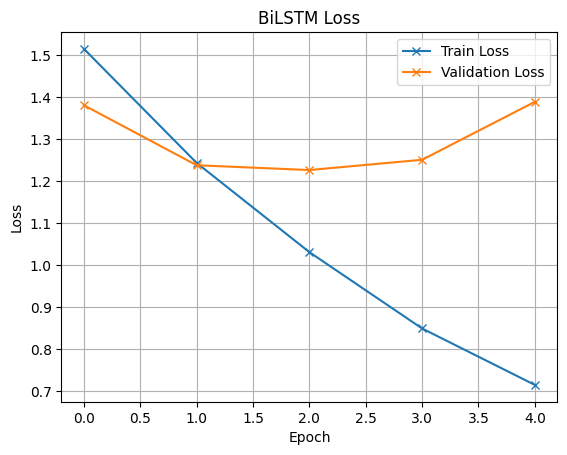

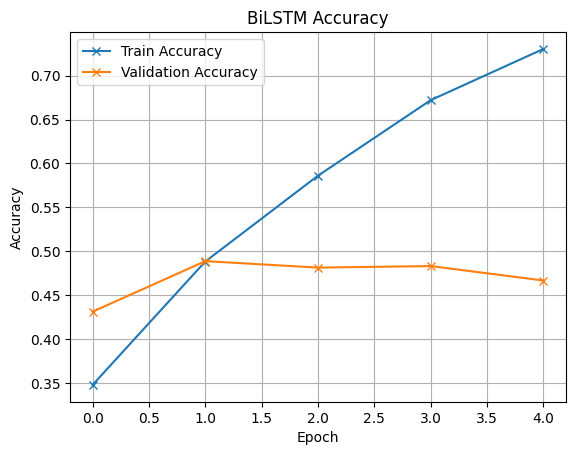

In [ ]:
bilstm_results = pd.DataFrame({
    "Configuration": ["BiLSTM 1", "BiLSTM 2", "BiLSTM 3"],
    "Validation Accuracy": [acc_bilstm_1, acc_bilstm_2, acc_bilstm_3],
    "Validation Macro F1": [f1_bilstm_1, f1_bilstm_2, f1_bilstm_3],
})
print(bilstm_results)

if (f1_bilstm_1 >= f1_bilstm_2) and (f1_bilstm_1 >= f1_bilstm_3):
    best_bilstm_name = "BiLSTM 1"
    bilstm_val_f1 = f1_bilstm_1
    best_bilstm_model = model_bilstm_1
    history_best_bilstm = history_bilstm_1
elif f1_bilstm_2 >= f1_bilstm_3:
    best_bilstm_name = "BiLSTM 2"
    bilstm_val_f1 = f1_bilstm_2
    best_bilstm_model = model_bilstm_2
    history_best_bilstm = history_bilstm_2
else:
    best_bilstm_name = "BiLSTM 3"
    bilstm_val_f1 = f1_bilstm_3
    best_bilstm_model = model_bilstm_3
    history_best_bilstm = history_bilstm_3

bilstm_test_pred = np.argmax(best_bilstm_model.predict(X_test_seq), axis=1)
bilstm_test_acc = accuracy_score(y_test_id, bilstm_test_pred)
bilstm_test_f1 = f1_score(y_test_id, bilstm_test_pred, average="macro")
print("Best BiLSTM configuration:", best_bilstm_name)
print("Test Accuracy:", bilstm_test_acc)
print("Test Macro F1:", bilstm_test_f1)
print(classification_report(y_test_id, bilstm_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, bilstm_test_pred))

plt.plot(history_best_bilstm.history["loss"], label="Train Loss", marker="x")
plt.plot(history_best_bilstm.history["val_loss"], label="Validation Loss", marker="x")
plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_best_bilstm.history["accuracy"], label="Train Accuracy", marker="x")
plt.plot(history_best_bilstm.history["val_accuracy"], label="Validation Accuracy", marker="x")
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Member 4 — BERT Base




In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return bert_tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

train_hf = Dataset.from_pandas(pd.DataFrame({
    "text": list(X_train_text),
    "label": list(y_train_id),
}))
val_hf = Dataset.from_pandas(pd.DataFrame({
    "text": list(X_val_text),
    "label": list(y_val_id),
}))
test_hf = Dataset.from_pandas(pd.DataFrame({
    "text": list(X_test_text),
    "label": list(y_test_id),
}))

train_hf = train_hf.map(tokenize, batched=True)
val_hf = val_hf.map(tokenize, batched=True)
test_hf = test_hf.map(tokenize, batched=True)

train_hf = train_hf.rename_column("label", "labels")
val_hf = val_hf.rename_column("label", "labels")
test_hf = test_hf.rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/9240 [00:00<?, ? examples/s]

Map:   0%|          | 0/2310 [00:00<?, ? examples/s]

Map:   0%|          | 0/2888 [00:00<?, ? examples/s]

In [ ]:
bert_model_1 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5,
)
training_args_1 = TrainingArguments(
    output_dir="./bert_config1",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    logging_steps=50,
    eval_strategy="epoch",
)
trainer_1 = Trainer(
    model=bert_model_1,
    args=training_args_1,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_1.train()
bert_val_1 = trainer_1.predict(val_hf)
bert_val_pred_1 = np.argmax(bert_val_1.predictions, axis=1)
bert_acc_1 = accuracy_score(y_val_id, bert_val_pred_1)
bert_f1_1 = f1_score(y_val_id, bert_val_pred_1, average="macro")
print("BERT Configuration 1")
print("Validation Accuracy:", bert_acc_1)
print("Validation Macro F1:", bert_f1_1)


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.889431,0.899478,0.635931,0.635193


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Configuration 1
Validation Accuracy: 0.6359307359307359
Validation Macro F1: 0.6351933767702975


In [ ]:
bert_model_2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5,
)
training_args_2 = TrainingArguments(
    output_dir="./bert_config2",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    logging_steps=50,
    eval_strategy="epoch",
)
trainer_2 = Trainer(
    model=bert_model_2,
    args=training_args_2,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_2.train()
bert_val_2 = trainer_2.predict(val_hf)
bert_val_pred_2 = np.argmax(bert_val_2.predictions, axis=1)
bert_acc_2 = accuracy_score(y_val_id, bert_val_pred_2)
bert_f1_2 = f1_score(y_val_id, bert_val_pred_2, average="macro")
print("BERT Configuration 2")
print("Validation Accuracy:", bert_acc_2)
print("Validation Macro F1:", bert_f1_2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.908920,0.912102,0.634632,0.631626
2,0.728510,0.880541,0.634632,0.629669


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Configuration 2
Validation Accuracy: 0.6346320346320347
Validation Macro F1: 0.6296691144767068


In [ ]:
bert_model_3 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5,
)
training_args_3 = TrainingArguments(
    output_dir="./bert_config3",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    logging_steps=50,
    eval_strategy="epoch",
)
trainer_3 = Trainer(
    model=bert_model_3,
    args=training_args_3,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_3.train()
bert_val_3 = trainer_3.predict(val_hf)
bert_val_pred_3 = np.argmax(bert_val_3.predictions, axis=1)
bert_acc_3 = accuracy_score(y_val_id, bert_val_pred_3)
bert_f1_3 = f1_score(y_val_id, bert_val_pred_3, average="macro")
print("BERT Configuration 3")
print("Validation Accuracy:", bert_acc_3)
print("Validation Macro F1:", bert_f1_3)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.895637,0.928461,0.623377,0.622490
2,0.740112,0.892473,0.612554,0.614226
3,0.716443,0.895287,0.617749,0.612258


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Configuration 3
Validation Accuracy: 0.6177489177489177
Validation Macro F1: 0.6122582108399357


In [ ]:
bert_results = pd.DataFrame({
    "Configuration": ["BERT 1 epochs=1", "BERT 2 epochs=2", "BERT 3 epochs=3"],
    "Validation Accuracy": [bert_acc_1, bert_acc_2, bert_acc_3],
    "Validation Macro F1": [bert_f1_1, bert_f1_2, bert_f1_3],
})
print(bert_results)

if (bert_f1_1 >= bert_f1_2) and (bert_f1_1 >= bert_f1_3):
    best_bert_name = "BERT 1 epochs=1"
    bert_val_f1 = bert_f1_1
    best_bert_trainer = trainer_1
elif bert_f1_2 >= bert_f1_3:
    best_bert_name = "BERT 2 epochs=2"
    bert_val_f1 = bert_f1_2
    best_bert_trainer = trainer_2
else:
    best_bert_name = "BERT 3 epochs=3"
    bert_val_f1 = bert_f1_3
    best_bert_trainer = trainer_3

bert_test = best_bert_trainer.predict(test_hf)
bert_test_pred = np.argmax(bert_test.predictions, axis=1)
bert_test_acc = accuracy_score(y_test_id, bert_test_pred)
bert_test_f1 = f1_score(y_test_id, bert_test_pred, average="macro")
print("Best BERT configuration:", best_bert_name)
print("Test Accuracy:", bert_test_acc)
print("Test Macro F1:", bert_test_f1)
print(classification_report(y_test_id, bert_test_pred, target_names=target_names))
print(confusion_matrix(y_test_id, bert_test_pred))


     Configuration  Validation Accuracy  Validation Macro F1
0  BERT 1 epochs=1             0.635931             0.635193
1  BERT 2 epochs=2             0.634632             0.629669
2  BERT 3 epochs=3             0.617749             0.612258


Best BERT configuration: BERT 1 epochs=1
Test Accuracy: 0.6208448753462604
Test Macro F1: 0.6206641152407579
                                 precision    recall  f1-score   support

                      neoplasms       0.68      0.85      0.76       633
      digestive system diseases       0.55      0.69      0.61       299
        nervous system diseases       0.57      0.62      0.60       385
        cardiovascular diseases       0.65      0.81      0.72       610
general pathological conditions       0.58      0.33      0.42       961

                       accuracy                           0.62      2888
                      macro avg       0.61      0.66      0.62      2888
                   weighted avg       0.61      0.62      0.60      2888

[[538  18  20   7  50]
 [ 40 206   7   4  42]
 [ 30   6 240  34  75]
 [ 16  15  26 493  60]
 [163 132 125 225 316]]


# Final comparison



In [ ]:
final_results = pd.DataFrame({
    "Member": [
        "Member 1",
        "Member 1",
        "Member 2",
        "Member 2",
        "Member 2",
        "Member 3",
        "Member 3",
        "Member 3",
        "Member 4",
        "Member 4",
        "Shared",
    ],
    "Model": [
        "SimpleRNN",
        "Bidirectional SimpleRNN",
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "GRU",
        "Random Forest",
        "LSTM",
        "Bidirectional GRU",
        "Bidirectional LSTM",
        "BERT Base",
        "Word2Vec + Logistic Regression",
    ],
    "Representation": [
        "Keras Embedding",
        "Keras Embedding",
        "TF-IDF",
        "TF-IDF",
        "Keras Embedding",
        "TF-IDF",
        "Keras Embedding",
        "Keras Embedding",
        "Keras Embedding",
        "BERT tokenizer",
        "Word2Vec",
    ],
    "Configuration": [
        best_simplernn_name,
        best_bisimplernn_name,
        best_lr_name,
        best_nb_name,
        best_gru_name,
        best_rf_name,
        best_lstm_name,
        best_bigru_name,
        best_bilstm_name,
        best_bert_name,
        best_w2v_name,
    ],
    "Validation Score": [
        simplernn_val_f1,
        bisimplernn_val_f1,
        lr_val_f1,
        nb_val_f1,
        gru_val_f1,
        rf_val_f1,
        lstm_val_f1,
        bigru_val_f1,
        bilstm_val_f1,
        bert_val_f1,
        w2v_val_f1,
    ],
    "Test Accuracy": [
        simplernn_test_acc,
        bisimplernn_test_acc,
        lr_test_acc,
        nb_test_acc,
        gru_test_acc,
        rf_test_acc,
        lstm_test_acc,
        bigru_test_acc,
        bilstm_test_acc,
        bert_test_acc,
        w2v_test_acc,
    ],
    "Test F1": [
        simplernn_test_f1,
        bisimplernn_test_f1,
        lr_test_f1,
        nb_test_f1,
        gru_test_f1,
        rf_test_f1,
        lstm_test_f1,
        bigru_test_f1,
        bilstm_test_f1,
        bert_test_f1,
        w2v_test_f1,
    ],
})

print(final_results)

print("Results by member:")
print(final_results.groupby("Member")["Model"].apply(list))

best_row = final_results["Test F1"].idxmax()
worst_row = final_results["Test F1"].idxmin()
print("Best-performing model:")
print(final_results.loc[best_row])
print("Worst-performing model:")
print(final_results.loc[worst_row])


      Member                           Model   Representation  \
0   Member 1                       SimpleRNN  Keras Embedding   
1   Member 1         Bidirectional SimpleRNN  Keras Embedding   
2   Member 2             Logistic Regression           TF-IDF   
3   Member 2         Multinomial Naive Bayes           TF-IDF   
4   Member 2                             GRU  Keras Embedding   
5   Member 3                   Random Forest           TF-IDF   
6   Member 3                            LSTM  Keras Embedding   
7   Member 3               Bidirectional GRU  Keras Embedding   
8   Member 4              Bidirectional LSTM  Keras Embedding   
9   Member 4                       BERT Base   BERT tokenizer   
10    Shared  Word2Vec + Logistic Regression         Word2Vec   

      Configuration  Validation Score  Test Accuracy   Test F1  
0       SimpleRNN 1          0.297586       0.380540  0.302821  
1     BiSimpleRNN 2          0.304695       0.337604  0.307844  
2              LR 3     

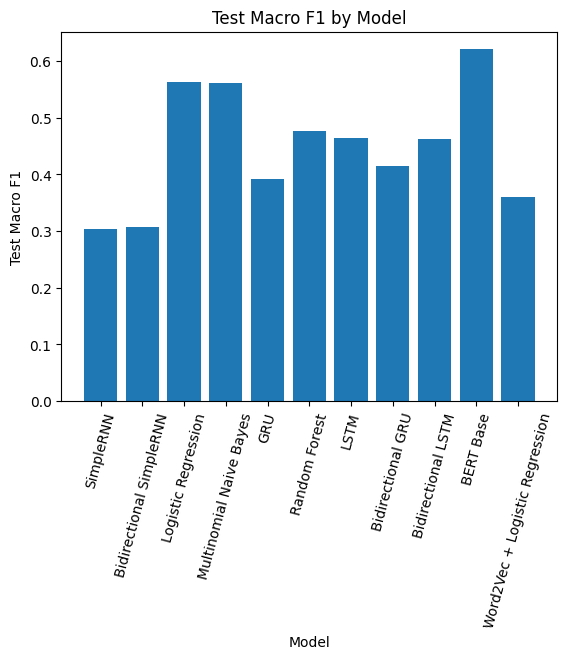

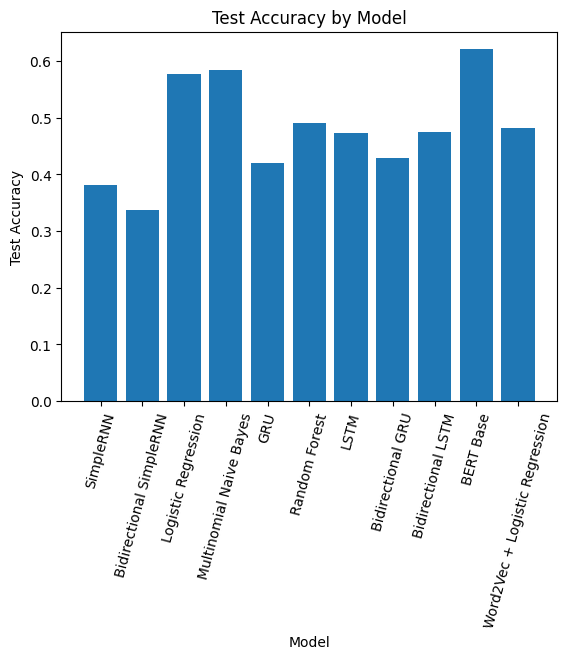

In [ ]:
plt.bar(final_results["Model"], final_results["Test F1"])
plt.title("Test Macro F1 by Model")
plt.xlabel("Model")
plt.ylabel("Test Macro F1")
plt.xticks(rotation=75)
plt.show()

plt.bar(final_results["Model"], final_results["Test Accuracy"])
plt.title("Test Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=75)
plt.show()
